# Capítulo 8 - Classificação de Imagem

## 8.1 Introdução à ConvNets

**Exemplo simples de ConvNet:** o modelo usa uma ConvNet para classificar dígitos do MNIST, uma tarefa que realizamos no capítulo 2 usando uma rede densamente conectada (nossa precisão de teste na época foi de 97,8%). Mesmo que a ConvNet seja básica, sua precisão será muito superior à do modelo densamente conectado do capítulo 2.

### Instanciando uma pequena ConvNet

In [6]:
import keras
from keras import layers

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

É importante notar que uma ConvNet recebe como entrada tensores de formato (altura_da_imagem, largura_da_imagem,
canais_da_imagem) (sem incluir a dimensão do batch). Neste caso, configuraremos a
ConvNet para processar entradas de tamanho (28, 28, 1), que é o formato das imagens MNIST.

Exibindo o sumário do modelo

In [2]:
# O método .summary() pode ser usado para exibir a arquitetura da rede

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

Após a última camada `Conv2D`, terminamos com um output de forma (3, 3, 256) - um mapa de características 3x3 com 256 canais.

Em seguida, essa saída é passada para um classificador densamente conectado, como aqueles com os quais você já está familiarizado: uma pilha de camadas Dense. Esses classificadores
processam vetores, que são 1D, enquanto a saída atual é um tensor de rank-3. Para preencher essa lacuna, achatamos as saídas 3D para 1D com uma camada GlobalAveragePooling2D antes de adicionar as camadas Dense. Essa camada calculará a média de cada mapa de características 3×3 no tensor de formato (3, 3, 256), resultando em um vetor de saída de formato (256,)

### Treinando a ConvNet com as imagens do MNIST

In [3]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 114s 120ms/step - accuracy: 0.9197 - loss: 0.2546
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 105s 112ms/step - accuracy: 0.9768 - loss: 0.0742
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 106s 114ms/step - accuracy: 0.9841 - loss: 0.0500
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 115ms/step - accuracy: 0.9888 - loss: 0.0380
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 106s 113ms/step - accuracy: 0.9903 - loss: 0.0308


### Avaliando a ConvNet

In [4]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9904 - loss: 0.0316
Test accuracy: 0.990


Enquanto o modelo densamente conectado tinha uma acurácia de 97.8%, a ConvNet básica tem uma precisão de teste de 99.0%, diminuímos a taxa de erro em cerca de 50%.

### 8.1.1 A operação de convolução

A diferença fundamental entre uma camada densamente conectada e uma camada de convolução é a seguinte: as camadas densas aprendem padrões globais em seu espaço de características de entrada (por exemplo, para um dígito do MNIST, padrões envolvendo pixels), enquanto uma camada de convolução aprende padrões locais, no caso de imagens, padrões encontrados em pequenas janelas 2D dos inputs. Essa característica fundamental confere à rede duas propriedades interessates:

- **Os padrões que aprendem são invariantes à translação**. Depois de aprender um determinado padrão no canto inferior direito de uma imagem, uma ConvNet pode reconhecê-lo em qualquer lugar: por exemplo, no canto superior esquerdo. Isso torna os ConvNets eficientes em termos de dados no processamento de imagens, já que o mundo visual é fundamentalmente invariante à translação. Eles precisam de menos amostras de treinamento para aprender representações que têm poder de generalização.

- Elas podem aprender **hierarquias espaciais de padrões**. Uma primeira camada de convolução aprenderá pequenos padrões locais, como bordas; uma segunda camada de convolução aprenderá padrões maiores, compostos pelas características das primeiras camadas; e assim por diante. Isso permite que as ConvNets aprendam com eficiência conceitos visuais cada vez mais complexos e abstratos, porque **o mundo visual é fundamentalmente hierárquico espacialmente.**

Convoluções são definidas por dois parâmetros principais:

- Tamanho dos patches extraídos dos inputs.

- Profundidade do mapa de características - O número de filtros computados por convolução. O exemplo anterior iniciou com uma profundidade de 64 canais e terminou com 256.

Uma convolução funciona deslizando janelas de tamanho 3×3 ou 5×5 sobre o mapa de características de entrada 3D, parando em cada localização possível e extraindo o patch 3D de
características circundantes de formato ((altura_da_janela, largura_da_janela, profundidade_de_entrada)). Cada patch 3D é então transformado em um vetor 1D de formato (profundidade_de_saída), o que é feito por meio de um produto tensorial com uma matriz de pesos aprendida, chamada kernel de convolução — o mesmo kernel é reutilizado em todos os patches. Todos esses vetores (um por patch) são então remontados espacialmente em um mapa de saída 3D de formato (altura, largura, profundidade_de_saída).

Observe que a largura e a altura da saída podem ser diferentes da largura e da altura da entrada. Isso pode ocorrer por dois motivos:
- Efeitos de borda, que podem ser atenuados com o preenchimento do mapa de recursos de entrada;
- O uso de strides (passos), que definiremos em seguida.

#### Entendo os efeitos de borda e o preenchimento

Considere um mapa de características de 5×5 (25 blocos no total). Existem apenas 9 blocos em torno dos quais você pode centralizar uma janela de 3×3, formando uma grade de 3×3. Portanto, o mapa de características resultante será de 3×3. Ele encolhe um pouco: exatamente dois blocos em cada dimensão, neste caso.

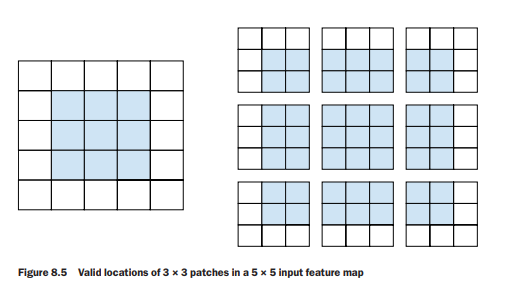

Se você deseja obter um mapa de características de saída com as mesmas dimensões espaciais da entrada, pode usar o preenchimento (padding). O preenchimento consiste em adicionar um número apropriado de linhas e colunas em cada lado do mapa de características de entrada, de forma a possibilitar o ajuste de janelas de convolução centradas em torno de cada bloco de entrada.


Nas camadas `Conv2D`, o preenchimento é configurável através do argumento `padding`, que aceita dois
valores: `valid`, que significa nenhum preenchimento (apenas locais de janela válidos serão usados);
e `same`, que significa "preencher de forma a ter uma saída com a mesma largura
e altura da entrada". O argumento `padding` tem como padrão o valor "valid".

Entendendo os strides da convolução

O outro fator que pode influenciar o tamanho do output são os strides. A descrição da convolução presupôs que os blocos centrais são todos contíguos. No entanto, a distância de duas janelas sucessivas é um parâmetro da convolução,denominado stride, que por padrão é 1.

É possível ter convoluções com stride: convoluções com um stride maior que 1. Na figura, é possível ver os patches extraídos por uma convolução 3x3 com stride igual a 2 sobre um input 5x5.



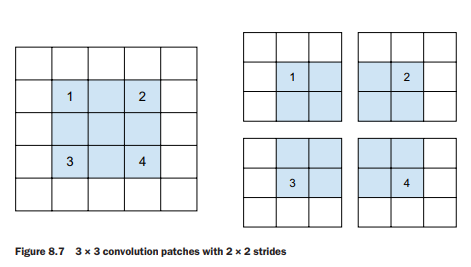

### 8.1.2 A operação de max-pooling

 **Função do max pooling:** reduzir agressivamente a resolução dos mapas de características, de forma semelhante às convoluções com stride.

 O max pooling consiste em extrair janelas dos mapas de características de entrada e gerar o valor máximo de cada canal. É conceitualmente semelhante à convolução, exceto que, em vez de transformar patches locais por meio de uma transformação linear aprendida (o kernel de convolução), eles são transformados por meio de uma operação de tensor `max` predefinida.

 Uma grande diferença em relação à convolução é que o max pooling geralmente é feito com janelas 2×2 e passo 2 para reduzir a resolução dos mapas de características pela metade. Por outro lado, a convolução normalmente é feita com janelas 3×3 e sem passo (stride=1).

## 8.2 Treinando uma ConvNet a partir do zero com um dataset pequeno

Como exemplo prático, vamos classificar imagens como cães ou gatos. Trabalharemos com um conjunto de dados contendo 5.000 fotos de gatos e cães (2.500 gatos, 2.500 cães), retiradas do conjunto de dados original do Kaggle. Usaremos 2.000 fotos para treinamento, 1.000 para validação e 2.000 para teste.

Começaremos treinando uma pequena ConvNet com 2.000 amostras de treinamento sem qualquer regularização para estabelecer uma base de referência para o que pode ser alcançado. Isso nos levará a uma acurácia de classificação de cerca de 80%. Nesse ponto, o principal problema será o overfitting. Em seguida, introduziremos o data augmentation, uma técnica poderosa para mitigar o sobreajuste em visão computacional. Usando o aumento de dados, melhoraremos o modelo para atingir uma acurácia de teste de cerca de 84%.

Na próxima seção, revisaremos mais duas técnicas essenciais para aplicar aprendizado profundo a conjuntos de dados pequenos: extração de características com um modelo pré-treinado e ajuste fino de um modelo pré-treinado (o que nos levará a uma precisão final de 98,5%).

### 8.2.2 Baixando os dados

**Baixando um conjunto de dados do Kaggle no Google Colaboratory**

O Kaggle disponibiliza uma API fácil de usar para baixar conjuntos de dados hospedados no Kaggle programaticamente. Você pode usá-la para baixar o conjunto de dados Dogs vs. Cats para um notebook do Colab, por exemplo. Essa API está disponível por meio do pacote `kagglehub`, que já vem pré-instalado no Colab.

Antes de baixar o conjunto de dados, precisamos fazer duas coisas:

1. Acesse https://www.kaggle.com/c/dogs-vs-cats/rules e clique em "Participar da competição".

2. Acesse https://www.kaggle.com/settings e gere uma chave de API do Kaggle.

Com isso, estamos prontos para baixar os dados em seu notebook.

In [7]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


Então, baixando os dados da competição:

In [8]:
download_path = kagglehub.competition_download("dogs-vs-cats")

100%|██████████| 812M/812M [00:37<00:00, 22.8MB/s]

Extracting files...


Isso baixa dois novos arquivos, `train.zip` (os dados de treinamento) e `test1.zip` (os dados de teste). Usaremos apenas os dados de treinamento aqui. Vamos descompactá-los:

In [9]:
import zipfile

with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
  zip_ref.extractall(".") # ".": Esse parâmetro indica que os arquivos sejam
                          # descompactados no mesmo diretório do script atual

#### Copiando as imagens para os diretórios de treinamento, validação e teste

In [10]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")# Diretório original dos arquivos descompactados
new_base_dir = pathlib.Path("dogs_vs_cats_small") # Novo diretório

def make_subset(subset_name, start_index, end_index):
  # Função para copiar os arquivos para os subdiretório correspondentes
  for category in ("cat", "dog"):
    dir = new_base_dir / subset_name / category
    os.makedirs(dir)
    # Criando uma lista para nomear os arquivos copiados
    fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
    # Copiando os arquivos e alocando-os nos respectivos diretórios
    for fname in fnames:
      shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

# No colab, as pastas são criadas na pasta content, dentro da pasta dogs_vs_cats_small

### 8.2.3 Construindo o modelo

Vamos reutilizar a mesma estrutura geral de modelo que você viu no primeiro exemplo: a ConvNet será uma pilha de camadas alternadas de `Conv2D` (com ativação `relu`) e `MaxPooling2D`. Mas, como estamos lidando com imagens maiores e um problema mais complexo,
aumentaremos o tamanho do nosso modelo: ele terá mais dois estágios `Conv2D` `MaxPooling2D`. Isso serve tanto para aumentar a capacidade do modelo quanto para reduzir ainda mais o tamanho dos mapas de características, para que não fiquem muito grandes quando chegarmos à camada de pooling. Aqui,
como começamos com entradas de tamanho 180×180 pixels (uma escolha um tanto arbitrária),
acabamos com mapas de características de tamanho 7×7 logo antes da camada `GlobalAveragePooling2D`.

Como estamos lidando com um problema de classificação binária, finalizaremos o modelo com uma
unidade única (uma camada Densa de tamanho 1) e uma ativação `sigmoid`. Essa unidade codificará a
probabilidade de o modelo estar considerando uma classe ou outra.

Uma última pequena diferença: iniciaremos o modelo com uma camada `Rescaling`, que redimensionará as entradas de imagem (cujos valores estão originalmente no intervalo [0, 255]) para o intervalo [0, 1].

#### Instanciando uma pequena ConvNet para a classificação cães vs. gatos

In [11]:
import keras
from keras import layers

inputs = keras.Input(shape=(180, 180, 3)) # O modelo espera um imagem de 180x180
                                          # com canais RGB referente às cores
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
# Achata as ativações 3D com formato (altura, largura, 512) em ativações
# 1D com forma (512,) calculando a média dos valores nas dimensões espaciais
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [12]:
# Note a evolução dos mapas de características com cada camada subsequente
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

#### Configurando o modelo para treinamento

In [13]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

### 8.2.4 Processamento de dados

Os dados devem ser formatados em tensores de ponto flutuante pré-processados ​​adequadamente antes de serem inseridos no modelo. Atualmente, os dados estão em um disco rígido como arquivos JPEG, portanto, as etapas para inseri-los no modelo são aproximadamente as seguintes:

1. Ler os arquivos de imagem.
2. Decodificar o conteúdo JPEG em grades RGB de pixels.
3. Convertê-las em tensores de ponto flutuante.
4. Redimensioná-las para um tamanho comum.
5. Empacote-as em batches (usaremos batches de 64 imagens).

Chamar `image_dataset_from_directory` primeiro listará os subdiretórios de `directory` e assumirá que cada um contém imagens de uma de suas classes. Em seguida,
indexará os arquivos de imagem em cada subdiretório. Finalmente, criará e retornará um objeto `tf.data.Dataset` configurado para ler esses arquivos, embaralhá-los, decodificá-los em tensores,
redimensioná-los para um tamanho compartilhado e agrupá-los em lotes.

Usando `image_dataset_from_directory` para ler as imagens dos diretórios

In [14]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


**Entendo os objetos TENSORFLOW DATASET**

API `tf.data` para criar fluxos de entrada (pipelines) eficientes para
modelos de aprendizado de máquina. Sua classe principal é `tf.data.Dataset`.

Um objeto `Dataset` é um iterador: você pode usá-lo em um `for`loop. Ele normalmente retorna batches de dados de entrada e labels. Você pode passar um objeto `Dataset` diretamente para o método `fit()` de um modelo Keras.

A classe `Dataset` lida com muitos recursos importantes que seriam complicados de implementar por conta própria, em particular a paralelização da lógica de pré-processamento em vários núcleos de CPU, bem como a pré-busca assíncrona de dados (pré-processamento do próximo lote de dados enquanto o anterior está sendo processado pelo modelo, o que mantém a execução fluindo sem interrupções).

A classe `Dataset` também permite a modificação dos conjuntos de dados. Entre os métodos disponíveis vale destacar:

- `map(callable)`: aplicará uma transformação arbitrária a cada elemento do conjunto de dados (a função `callable` deve receber como entrada um único elemento por vez fornecido pelo conjunto de dados).



**Ajustando o modelo**

In [13]:
# Exibindo as formas geradas pelo conjunto de dados.

for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [14]:
# Treinando o modelo usando Dataset

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath = "convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 321ms/step - accuracy: 0.5105 - loss: 0.6941 - val_accuracy: 0.5010 - val_loss: 0.6923
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.5485 - loss: 0.6850 - val_accuracy: 0.5060 - val_loss: 0.7091
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.6055 - loss: 0.6628 - val_accuracy: 0.6050 - val_loss: 0.6619
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.6060 - loss: 0.6602 - val_accuracy: 0.6480 - val_loss: 0.6436
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.6130 - loss: 0.6550 - val_accuracy: 0.5900 - val_loss: 0.6617
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.6380 - loss: 0.6389 - val_accuracy: 0.6570 - val_loss: 0.6333
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.6410 - loss: 0.6334 - val_accuracy: 0.6510 - val_loss: 0.6354
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.6635 - loss: 0.6166 - val_accuracy: 0.6

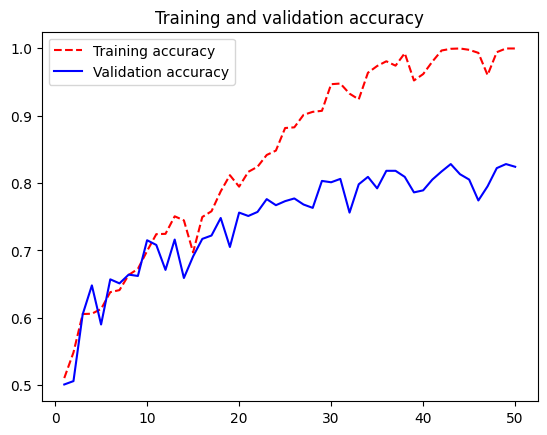

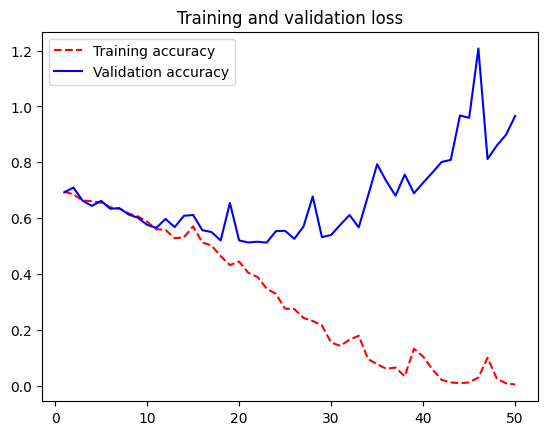

In [15]:
# Plotando as curvas de perda e acurácia produzidas durante o treinamento
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training accuracy")
plt.plot(epochs, val_loss, "b", label="Validation accuracy")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Esses gráficos são característicos de overfitting. A precisão do treinamento aumenta linearmente ao longo do tempo, até atingir quase 100%, enquanto a precisão da validação atinge um pico em torno de 80%. A perda de validação atinge seu mínimo após apenas 10 épocas e então se estabiliza, enquanto a perda de treinamento continua diminuindo linearmente à medida que o treinamento prossegue.

In [16]:
# Avaliando o modelo no conjunto de teste

test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc: .3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7660 - loss: 0.4944
Test accuracy:  0.766


### 8.2.5 Usando data augmentation

Data augmentation adota a abordagem de gerar mais dados de treinamento a partir de amostras existentes, aumentando a quantidade por meio de uma série de transformações aleatórias que produzem imagens com aparência verossímil. O objetivo é que, durante o treinamento, seu modelo nunca veja exatamente a mesma imagem duas vezes. Isso ajuda a expor o modelo a mais aspectos dos dados e a generalizar melhor.

In [15]:
# Definindo uma etapa de data augmentation

import tensorflow as tf

data_augmentation_layers = [
    layers.RandomFlip("horizontal"), # Aleatoriamente espelha a imagem
    layers.RandomRotation(0.1), # Gira aleatoriamente a imagem de 0 a 36 graus (10% de uma volta)
    layers.RandomZoom(0.2), # Aplica ou reduz, aleatoriamente, um zoom de até 20%
]

def data_augmentation(images, targets):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)

# Permite o pré-carregamento de lotes na memória
# da GPU; importante para o melhor desempenho
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

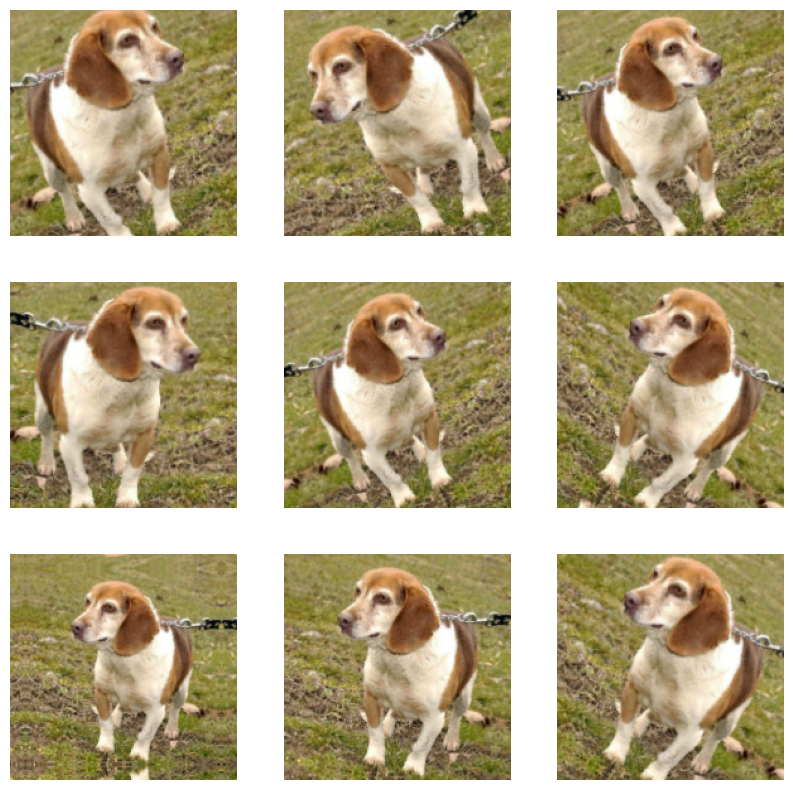

In [33]:
# Exibindo uma imagem de treinamento alteradas aleatoriamente.

plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
  image = image_batch[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image, _ = data_augmentation(image, None)
    augmented_image = keras.ops.convert_to_numpy(augmented_image)
    plt.imshow(augmented_image.astype("uint8"))
    plt.axis("off")

In [35]:
# Definindo uma nova ConvNet incluindo dropout

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)


Como esperamos que o sobreajuste ocorra muito mais tarde durante o treinamento, treinaremos pelo dobro de épocas —
100. Observe que avaliamos em imagens que não foram alteradas — data augmentation geralmente é realizado apenas durante o treinamento, pois é uma técnica de regularização.

In [36]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.4875 - loss: 0.6983 - val_accuracy: 0.5820 - val_loss: 0.6924
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 490ms/step - accuracy: 0.5135 - loss: 0.6917 - val_accuracy: 0.5920 - val_loss: 0.6809
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 490ms/step - accuracy: 0.5830 - loss: 0.6726 - val_accuracy: 0.5940 - val_loss: 0.6553
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step - accuracy: 0.6015 - loss: 0.6591 - val_accuracy: 0.5920 - val_loss: 0.6576
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 448ms/step - accuracy: 0.6345 - loss: 0.6405 - val_accuracy: 0.6680 - val_loss: 0.6186
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 501ms/step - accuracy: 0.6255 - loss: 0.6366 - val_accuracy: 0.6270 - val_loss: 0.6349
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.6655 - loss: 0.6196 - val_accuracy: 0.5080 - val_loss: 0.9791
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 431ms/step - accuracy: 0.6395 - loss: 0.6469 - 

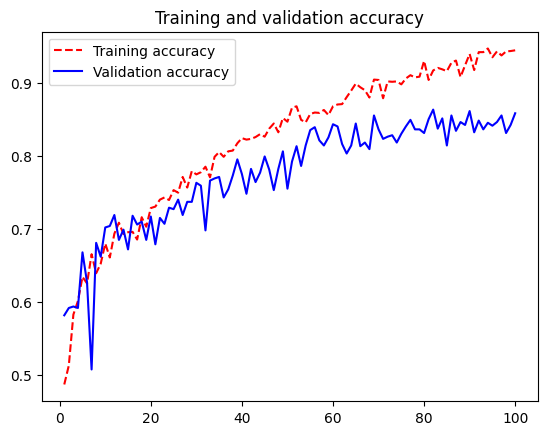

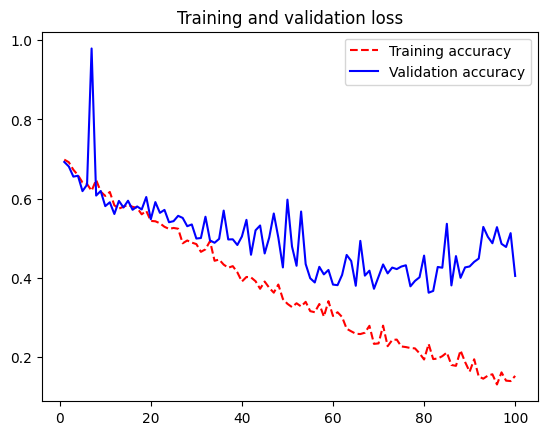

In [37]:
# Plotando as curvas de perda e acurácia produzidas durante o treinamento


accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training accuracy")
plt.plot(epochs, val_loss, "b", label="Validation accuracy")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [38]:
# Avaliando o modelo no conjunto de teste

test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc: .3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8445 - loss: 0.4351
Test accuracy:  0.845


## 8.3 Utilizando um modelo pré-treinado

Um modelo pré-treinado é um modelo que foi previamente treinado em um grande conjunto de dados, tipicamente em uma tarefa de classificação de imagens em larga escala. Se esse conjunto de dados original for grande o suficiente e geral o suficiente, a hierarquia espacial de características aprendida pelo modelo pré-treinado pode efetivamente atuar como um modelo genérico do mundo visual e, portanto, suas características podem ser úteis para muitos problemas diferentes de visão computacional, mesmo que esses novos problemas envolvam classes completamente diferentes daquelas da tarefa original.

Por exemplo, você pode treinar um modelo no ImageNet (onde as classes são
principalmente animais e objetos do cotidiano) e, em seguida, reaproveitar esse modelo treinado para algo tão remoto quanto identificar móveis em imagens.

### 8.3.1 Extração de características com um modelo pré-treinado

A extração de características consiste em usar as representações aprendidas por um modelo previamente treinado para extrair características interessantes de novas amostras. Essas características são então processadas por um novo classificador, que é treinado do zero.

As ConvNets usadas para classificação de imagens compreendem duas partes:
elas começam com uma série de camadas de pooling e convolução e terminam com um classificador densamente
conectado. A primeira parte é chamada de base convolucional ou espinha dorsal (Backbone) do modelo.

No caso das ConvNets, extração de características consiste em usar a base convulocional de uma rede treinada previamente, processar novos dados através dela, e treinar o novo classificador com base em sua saída.

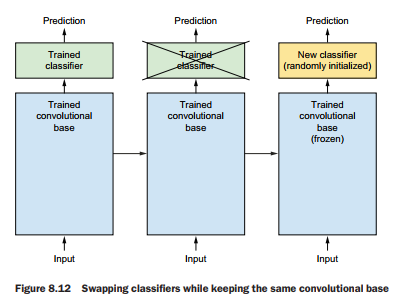

**Por que reutilizar apenas a base convolucional?**

A razão é que as representações aprendidas pela base convolucional tendem a ser mais genéricas e, portanto, mais reutilizáveis: os mapas de características de uma ConvNet são mapas de presença de conceitos genéricos
sobre uma imagem, o que provavelmente será útil independentemente do problema de visão computacional em questão.

Mas as representações aprendidas pelo classificador serão necessariamente específicas para o conjunto de classes no qual o modelo foi treinado — elas conterão apenas informações sobre a probabilidade de presença desta ou daquela classe em toda a imagem.

Note que o nível de generalidade (e, portanto, de reutilização) das representações extraídas por camadas convolucionais específicas depende da profundidade da camada no modelo. Camadas que vêm no início do modelo extraem mapas de características locais e altamente genéricos (como bordas visuais, cores e texturas), enquanto camadas mais acima extraem conceitos mais abstratos (como "orelha de gato" ou "olho de cachorro").

Portanto, se o seu novo conjunto de dados for muito diferente do conjunto de dados no qual o modelo original foi treinado, pode ser melhor usar apenas as primeiras camadas do modelo para extrair características, em vez de usar toda a base convolucional.

In [16]:
# O modelo pré-treinado usado: Xception

import keras_hub
# construtor especial chamado from_preset() baixa a configuração e os pesos
# para o modelo Xception. 41 refere-se ao número de camadas do modelo.
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")



Toda ConvNet pré-treinada realiza algum redimensionamento e reescala das imagens antes do pré-treinamento.
É importante garantir que nossas imagens de entrada correspondam; caso contrário, nosso modelo precisará
reaprender como extrair recursos de imagens com um intervalo de entrada totalmente diferente. Em vez de
manter o controle de quais modelos pré-treinados usam um intervalo de entrada [0, 1] para valores de pixel
e quais usam um intervalo [-1, 1], podemos usar uma camada do KerasHub chamada ImageConverter que
redimensionará nossas imagens para corresponder ao nosso ponto de verificação pré-treinado.

In [17]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180)
)

O livro mostrou duas formas de usar a extração pelo modelo pré-treinado:

1 - Usando a base convolucional para processar as imagens e registrando a saída em um NumPy array. Então usando esses dados como entrada para um classificador densamente conectado. Esse método é mais rápido, mas não permite o uso de data augmentation.

2 - Extendendo o modelo `conv_base` adicionando uma camada `Dense` e executando tudo, de ponta a ponta, com as imagens como input. Essa forma permite o uso de data augmentation.

**Rápida extração sem data augmentation**

In [19]:
import numpy as np

def get_features_and_labels(dataset):
  all_features = []
  all_labels = []
  for images, labels in dataset:
    preprocessed_images = preprocessor(images)
    features = conv_base.predict(preprocessed_images, verbose=0)
    all_features.append(features)
    all_labels.append(labels)
  return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

print(train_features.shape)

(2000, 6, 6, 2048)


In [20]:
# Definindo e treinando o classificador densamente conectado

inputs = keras.Input(shape=(6, 6, 2048))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9640 - loss: 0.0877 - val_accuracy: 0.9790 - val_loss: 0.0582
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9865 - loss: 0.0378 - val_accuracy: 0.9730 - val_loss: 0.0890
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9900 - loss: 0.0279 - val_accuracy: 0.9840 - val_loss: 0.0502
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9950 - loss: 0.0139 - val_accuracy: 0.9840 - val_loss: 0.0487
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9975 - loss: 0.0061 - val_accuracy: 0.9830 - val_loss: 0.0590
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9990 - loss: 0.0036 - val_accuracy: 0.9860 - val_loss: 0.0566
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9880 - val_loss: 0.0550
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 8.8650e-04 - val_accuracy: 0.9840

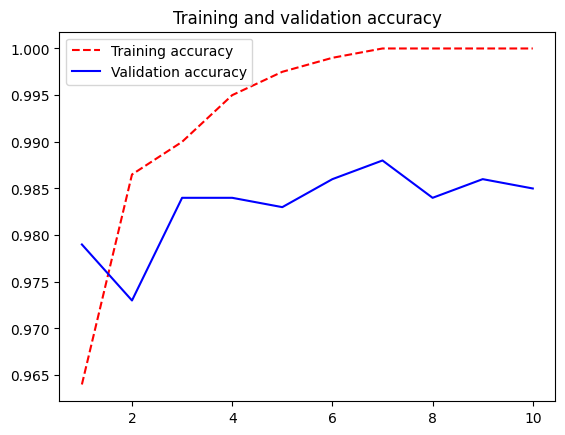

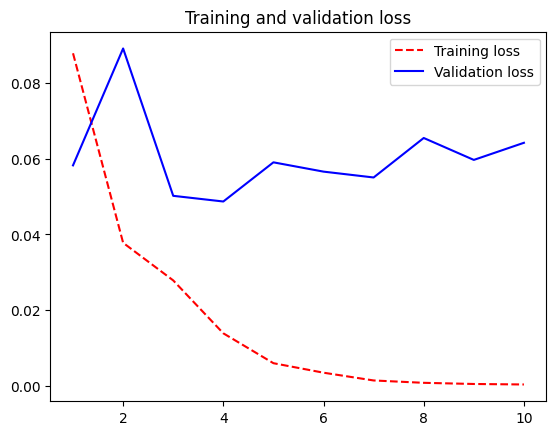

In [22]:
# Plotando os resultados

import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Éalcançada uma precisão de validação de pouco mais de 98% — muito melhor do que a obtida na seção anterior com o pequeno modelo treinado do zero. Essa comparação é um pouco injusta, no entanto, porque o ImageNet contém muitas instâncias de cães e gatos, o que significa que nosso modelo pré-treinado já possui o conhecimento exato necessário para a tarefa em questão. Isso nem sempre acontecerá quando você usar recursos pré-treinados.

No entanto, os gráficos também indicam que você está sofrendo overfitting quase desde o início — apesar de usar dropout com uma taxa bastante alta. Isso ocorre porque essa técnica não usa data augmentation, que é essencial para evitar overfitting com conjuntos de dados de imagens reduzidos.

In [23]:
# Avaliando o modelo no conjunto de teste

test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc: .3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9855 - loss: 0.0571
Test accuracy:  0.985


**Extração de características com data augmentation**

Essa técnica trata-se de cria um modelo que encadeie a `conv_base` com um novo classificador denso e treiná-lo de ponta a ponta nas entradas.

Para tanto, primeiro congelaremos a base convulocional. *Freezing* uma camada ou um conjunto de camadas significa impedir que seus pesos sejam atualizados durante o treinamento. Aqui, se você não
fizer isso, as representações previamente aprendidas pela base convolucional
serão modificadas durante o treinamento.

Como as camadas `Dense` no topo são inicializadas aleatoriamente, atualizações de peso muito grandes seriam propagadas pela rede, efetivamente
destruindo as representações aprendidas anteriormente.

In [24]:
# Criando uma base convolucional congelada

import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [25]:
# Modelo com backbone do Xception e data augmentation

inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# Com essa montagem, apenas os pesos das duas camadas Dense serão treinados.

# Note que para as mudanças terem efeito, é preciso compilar o modelo.

# Se modificar o treinamento dos pesos após a compilação, o modelo precisa ser
# recompilado.

In [ ]:
# Devido a data augmentation, o modelo vai demorar muito mais tempo
# para sofrer overfitting, então podemos treiná-lo por mais
# épocas nesse caso 30:

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9965 - loss: 0.0081 - val_accuracy: 0.9420 - val_loss: 0.2166
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 770ms/step - accuracy: 0.9895 - loss: 0.0359 - val_accuracy: 0.9130 - val_loss: 0.3832
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 929ms/step - accuracy: 0.9895 - loss: 0.0255 - val_accuracy: 0.9600 - val_loss: 0.2019
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 835ms/step - accuracy: 0.9950 - loss: 0.0147 - val_accuracy: 0.9550 - val_loss: 0.1376
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 766ms/step - accuracy: 0.9930 - loss: 0.0229 - val_accuracy: 0.9640 - val_loss: 0.1653
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 760ms/step - accuracy: 0.9955 - loss: 0.0169 - val_accuracy: 0.9550 - val_loss: 0.1557
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 965ms/step - accuracy: 0.9925 - loss: 0.0275 - val_accuracy: 0.9630 - val_loss: 0.1092
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 788ms/step - accuracy: 0.9965 - loss: 0.0141 - val_accurac

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [28]:
# Avaliando o modelo com o conjunto de teste

test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.9595 - loss: 0.1132
Test accuracy: 0.960


### 8.3.2 Ajuste fino do modelo pré-treinado

O ajuste fino consiste em descongelar o modelo base usado para extração de características e treinar conjuntamente a parte recém-adicionada do modelo (neste caso, o classificador totalmente conectado) e o modelo base.

Só é possível ajustar a base convolucional depois que o classificador acima já tiver sido treinado. Se o classificador ainda não estiver treinado, o sinal de erro que se propaga pela rede durante o treinamento será muito grande e as representações aprendidas anteriormente pelas camadas que estão sendo ajustadas serão destruídas.

Assim, os passo para o ajuste fino são:

1. Adicionar a rede personalizada à rede base já treinada.

2. Congelar a rede base.

3. Treinar a parte de rede adicionada.

4. Descongelar a rede base.

5. Treinar juntamente ambas as partes.

Vamos começar a ajustar o modelo usando uma taxa de aprendizado muito baixa. O intuito dessa opção é limitar a magnitude das modificações que faz nas representações das camadas que você está ajustando. Atualizações muito grandes podem prejudicar essas representações.

In [ ]:
# Ajuste fino do modelo

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
# Avaliando o modelo com o cojunto de teste

model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")